# Лабораторная работа №1
## Сжатие изображений с помощью SVD

**Выполнил:** Чубаев Кирилл Евгеньевич  
**Группа:** НПМбд-01-24  
**Преподаватель:** Карандашев Я. М.

### Запуск в Google Colab
Откройте этот файл в Colab и выберите **«Среда выполнения → Выполнить все»**.
Достаточно обычной среды Python с CPU; GPU не требуется. Изображение загружается автоматически из интернета,
ручная загрузка файлов и подключение Google Drive не нужны. Результаты сохраняются в папке `svd_results`
текущей среды; их можно скачать через панель «Файлы». Используются NumPy, Matplotlib, Pillow и scikit-learn.
Сохранённые выводы позволяют просмотреть отчёт до повторного запуска.


## 1. Цель работы
Освоить сингулярное разложение матриц и применить его к сжатию цветного растрового изображения.
Исследовать влияние ранга на визуальное качество, среднеквадратичную ошибку и объём хранения;
сопоставить теоретический размер коэффициентов с фактическим размером файлов.

## 2. Основная часть. Теоретические сведения
Для матрицы канала $A\in\mathbb{R}^{h\times w}$ экономное SVD имеет вид
$A=U\operatorname{diag}(s)V^T$, где $k=\min(h,w)$,
$U\in\mathbb{R}^{h\times k}$, $s\in\mathbb{R}^{k}$, $V^T\in\mathbb{R}^{k\times w}$.
Столбцы $U$ и строки $V^T$ ортонормированы, сингулярные числа упорядочены по убыванию.

Сохраняя первые $r$ компонент, получаем
$A_r=(U_{:,1:r}\odot s_{1:r})V^T_{1:r,:}$.
Умножение на $s$ выполняется по столбцам посредством broadcasting — без создания диагональной матрицы.
По теореме Эккарта–Янга это лучшее приближение ранга **не выше** $r$ в норме Фробениуса:
$\|A-A_r\|_F^2=\sum_{i=r+1}^{k}s_i^2$.
RGB обрабатывается по трём каналам независимо, один и тот же ранг используется для каждого канала.

Вычисления выполняются в `float64`, коэффициенты для хранения переводятся в `float32`.
Для отображения результат ограничивается диапазоном 0–255, округляется и преобразуется в `uint8`.
После ограничения и округления матрица уже не обязана иметь ранг $r$;
теоретическая формула ошибки относится к исходному вещественному приближению.


### Часть А. Загрузка и подготовка данных
Используется фотография astronaut из набора scikit-image (512×512, RGB).
[Описание и происхождение изображения](https://scikit-image.org/docs/stable/api/skimage.data.html#skimage.data.astronaut).
Ссылка на файл привязана к версии репозитория, чтобы повторные запуски использовали один набор данных.


Размер: 512×512, каналы: 3, тип: uint8
Несжатый массив: 786,432 байт; скачанный PNG: 791,555 байт


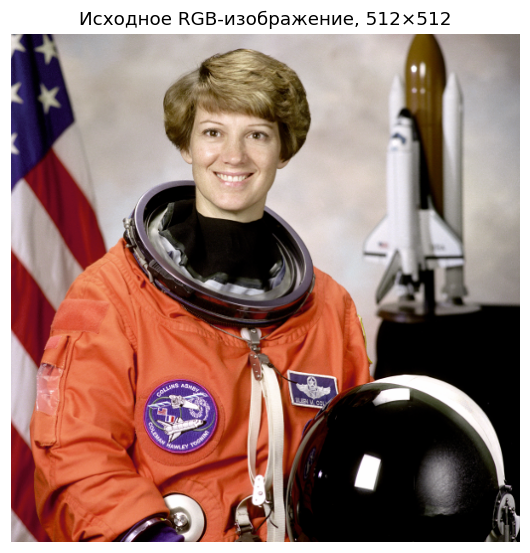

In [1]:
from pathlib import Path
from urllib.request import urlopen
from io import BytesIO
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error
from threadpoolctl import threadpool_limits

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
result_dir = Path('svd_results')
result_dir.mkdir(exist_ok=True)
image_url = 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png'

# Повторяем сетевой запрос при кратковременном сбое; не подменяем изображение.
for attempt in range(3):
    try:
        with urlopen(image_url, timeout=30) as response:
            image_bytes = response.read()
        with Image.open(BytesIO(image_bytes)) as loaded:
            img = loaded.convert('RGB')
        break
    except Exception:
        if attempt == 2:
            raise RuntimeError('Не удалось скачать изображение. Проверьте интернет и повторите запуск.')
        time.sleep(1)

(result_dir / 'original_download.png').write_bytes(image_bytes)
original = np.array(img, dtype=np.uint8)
original_shape = original.shape
h, w, c = original_shape
assert h >= 300 and w >= 300 and c == 3
original_float = original.astype(np.float64)
# float64 предотвращает переполнение при вычитании и возведении в квадрат uint8.
original_flat = original_float.flatten()
print(f'Размер: {w}×{h}, каналы: {c}, тип: {original.dtype}')
print(f'Несжатый массив: {original.nbytes:,} байт; скачанный PNG: {len(image_bytes):,} байт')
plt.figure(figsize=(6, 6))
plt.imshow(original)
plt.title('Исходное RGB-изображение, 512×512')
plt.axis('off')
plt.show()


**Результат части А.** Изображение прочитано через `PIL.Image.open()` и преобразовано в массив
`numpy.ndarray` размером (512, 512, 3). Выполнено усложнение: обе стороны больше 300 пикселей,
цвет сохранён. Несжатые пиксели занимают 786 432 байта (768 КиБ).
Объём PNG отличается: это файл с кодированием без потерь и служебными данными,
а не просто последовательность байтов RGB.


### Часть Б. SVD и восстановление для обязательных рангов


In [2]:
k = min(h, w)  # Для RGB нельзя брать min(original.shape): результатом было бы 3.
list_of_ranks = [1, 5, 10, 30, 100, k]
started = time.perf_counter()
# Разложение каждого канала вычисляем только один раз.
# Ограничение потоков уменьшает накладные расходы на небольших матрицах.
with threadpool_limits(limits=2):
    decompositions = [np.linalg.svd(original_float[:, :, channel], full_matrices=False)
                      for channel in range(c)]
print(f'SVD трёх каналов: {time.perf_counter() - started:.2f} с')
print('Размеры U, s, Vt:', [part.shape for part in decompositions[0]])

def reconstruct(rank, storage_dtype=None):
    """Восстановить RGB по rank компонентам каждого канала."""
    if not 1 <= rank <= k:
        raise ValueError(f'Ранг должен лежать в диапазоне 1…{k}')
    channels = []
    for U, s, Vt in decompositions:
        Ur, sr, Vtr = U[:, :rank], s[:rank], Vt[:rank, :]
        if storage_dtype is not None:
            Ur, sr, Vtr = [a.astype(storage_dtype) for a in (Ur, sr, Vtr)]
        channels.append((Ur * sr) @ Vtr)
    return np.stack(channels, axis=-1)

def to_uint8(array):
    return np.rint(np.clip(array, 0, 255)).astype(np.uint8)

with threadpool_limits(limits=2):
    raw_approximations = [reconstruct(r) for r in list_of_ranks]
approximations = [to_uint8(a) for a in raw_approximations]
mse_raw = [np.mean((original_float - a) ** 2) for a in raw_approximations]
mse_display = [np.mean((original_float - a.astype(np.float64)) ** 2)
               for a in approximations]
tail_mse = [sum(np.sum(s[r:] ** 2) for _, s, _ in decompositions) / original.size
            for r in list_of_ranks]
assert np.allclose(mse_raw, tail_mse, atol=1e-8, rtol=1e-9)
assert np.all(np.diff(mse_raw) <= 1e-8)
assert np.allclose(raw_approximations[-1], original_float, atol=1e-8, rtol=0)
assert np.array_equal(approximations[-1], original)
print('Полный ранг: максимальная ошибка до округления =',
      f'{np.max(np.abs(raw_approximations[-1] - original_float)):.3e}')
print('После округления полный ранг совпадает с исходными пикселями:',
      np.array_equal(approximations[-1], original))


SVD трёх каналов: 0.55 с
Размеры U, s, Vt: [(512, 512), (512,), (512, 512)]
Полный ранг: максимальная ошибка до округления = 1.532e-11
После округления полный ранг совпадает с исходными пикселями: True


**Результат части Б.** Выполнено три экономных SVD; матрицы восстановлены при
$r=1,5,10,30,100,512$. С ростом ранга добавляются пространственные детали.
Проверено совпадение численной MSE с суммой квадратов отброшенных сингулярных чисел.
При полном ранге вещественная ошибка определяется машинной точностью, а после округления
пиксели совпадают точно. Это утверждение о пикселях, а не о побайтовом совпадении файлов PNG.


### Часть В. Визуализация результатов


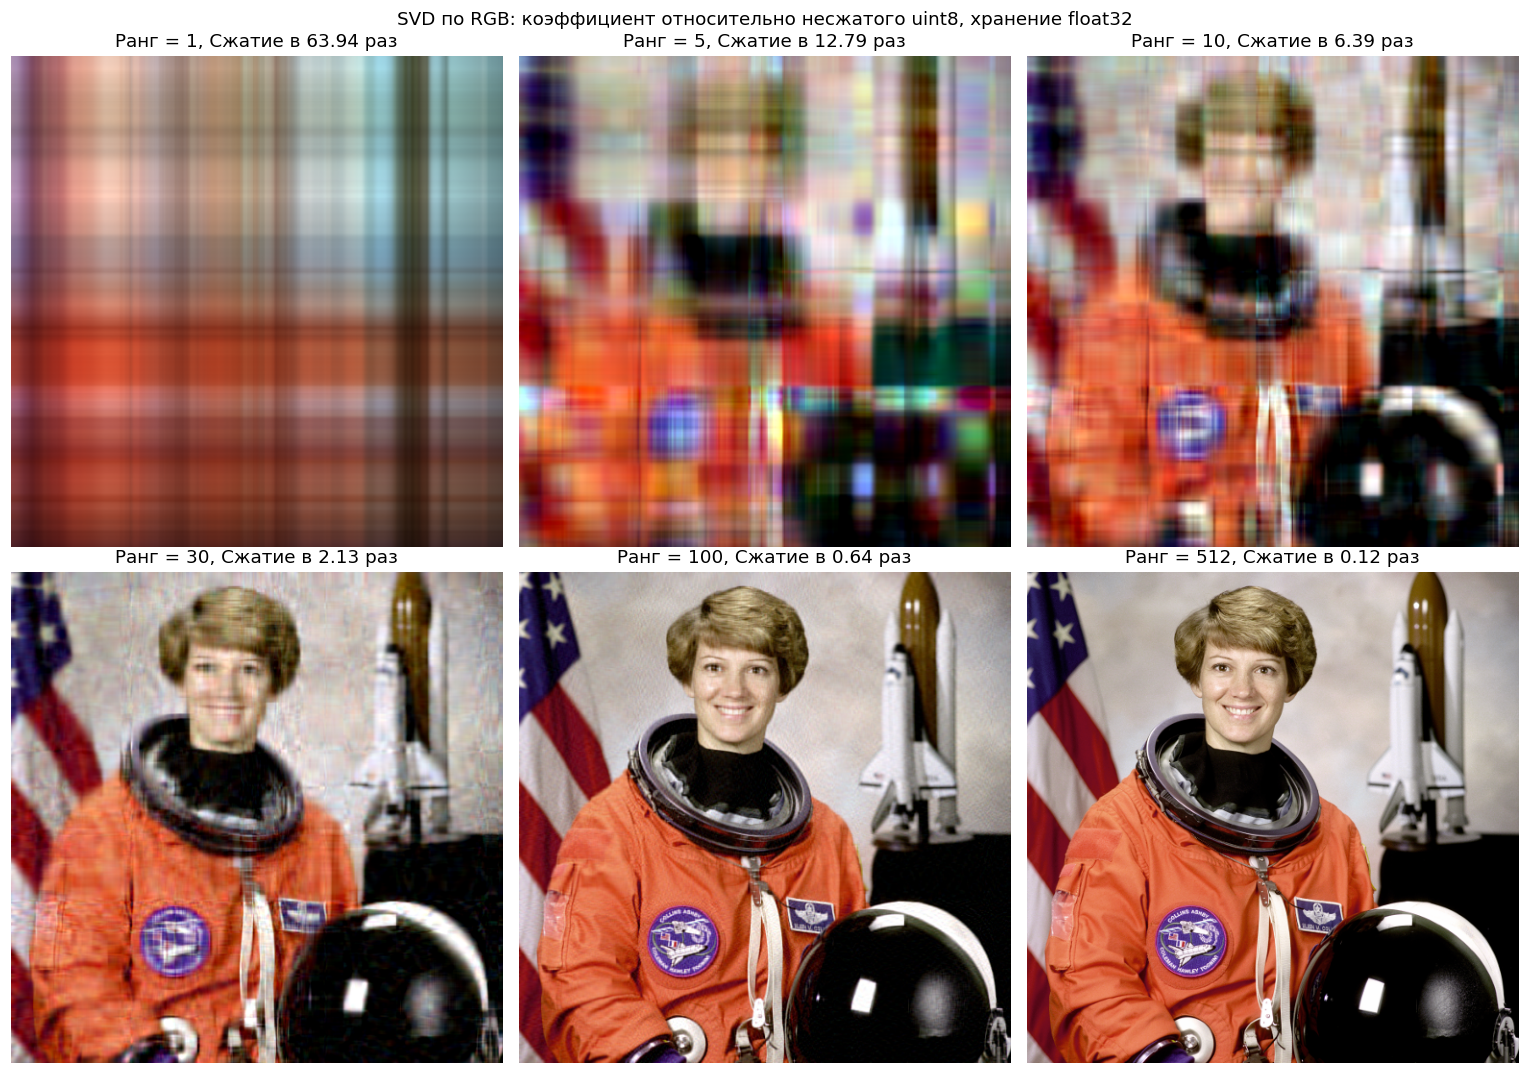

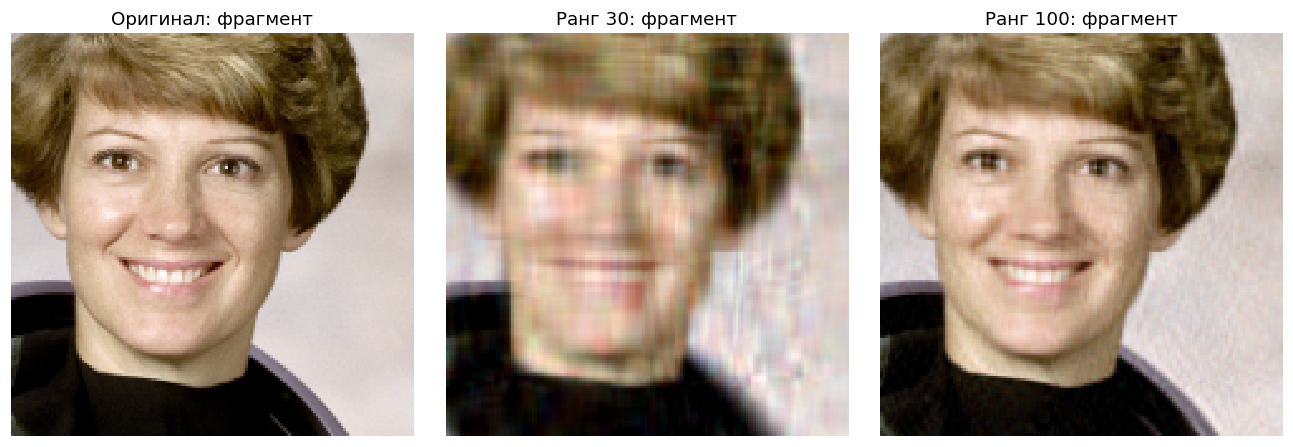

In [3]:
raw_bytes = original.nbytes
float_bytes = np.dtype(np.float32).itemsize
def factor_bytes(rank):
    return c * rank * (h + 1 + w) * float_bytes

compression_ratios = [raw_bytes / factor_bytes(r) for r in list_of_ranks]
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for ax, r, approx, ratio in zip(axes.flat, list_of_ranks, approximations, compression_ratios):
    ax.imshow(approx)
    ax.set_title(f'Ранг = {r}, Сжатие в {ratio:.2f} раз')
    ax.axis('off')
fig.suptitle('SVD по RGB: коэффициент относительно несжатого uint8, хранение float32')
fig.tight_layout()
fig.savefig(result_dir / 'comparison.png', bbox_inches='tight')
plt.show()

# Увеличенный фрагмент помогает оценить детали, скрытые на общей сетке.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
crop = (slice(50, 210), slice(160, 320))
for ax, arr, title in zip(axes, [original, approximations[3], approximations[4]],
                          ['Оригинал: фрагмент', 'Ранг 30: фрагмент', 'Ранг 100: фрагмент']):
    ax.imshow(arr[crop], interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')
fig.tight_layout()
plt.show()


**Результат части В.** При ранге 1 остаются преимущественно крупные цветовые области;
при 5 и 10 изображение узнаваемо, но детали размыты. Ранг 30 передаёт основные черты,
однако мелкие детали ещё потеряны. При ранге 100 качество близко к исходному в общей сетке,
но увеличенный фрагмент позволяет заметить различия. Точное совпадение обеспечивает ранг 512.
Подписи с коэффициентом меньше единицы означают увеличение объёма, а не экономию.


### Часть Г. Эффективность сжатия и размер файлов
Для RGB в `uint8`: $B_0=3hw$ байт. Для трёх наборов факторов в `float32`:
$B_r=3r(h+w+1)\cdot4$ байт. Поэтому
$$K(r)=\frac{B_0}{B_r}=\frac{hw}{4r(h+w+1)}.$$
При 512×512: $B_r=12\,300r$, $K(r)\approx63.93756/r$.
Требование $K\ge10$ даёт $r\le\lfloor hw/[40(h+w+1)]\rfloor=6$.

Ниже реально сохраняются факторы `float32` в **NPZ без дополнительного сжатия** и
восстановленные изображения в PNG. NPZ включает заголовки массивов и контейнера;
его размер немного больше $B_r$. PNG хранит восстановленные пиксели, а не факторы SVD,
поэтому размер такого файла не описывается формулой $B_r$.


   r   Факторы, Б        K       NPZ, Б       PNG, Б    MSE uint8   PSNR, дБ
   1        12300   63.938        14452       187542    4241.2279      11.86
   5        61500   12.788        63652       282829    1572.1833      16.17
  10       123000    6.394       125152       313887     810.7558      19.04
  30       369000    2.131       371152       385763     239.4387      24.34
 100      1230000    0.639      1232152       451504      33.6838      32.86
 512      6297600    0.125      6299752       440419       0.0000        inf
Наибольший ранг для сжатия хотя бы в 10 раз: 6
K(6) = 10.656; K(7) = 9.134
Сжатие относительно RGB есть при целых рангах 1…63.
NPZ float32 прочитан и восстановлен; максимальное отклонение от float64: 0.000132


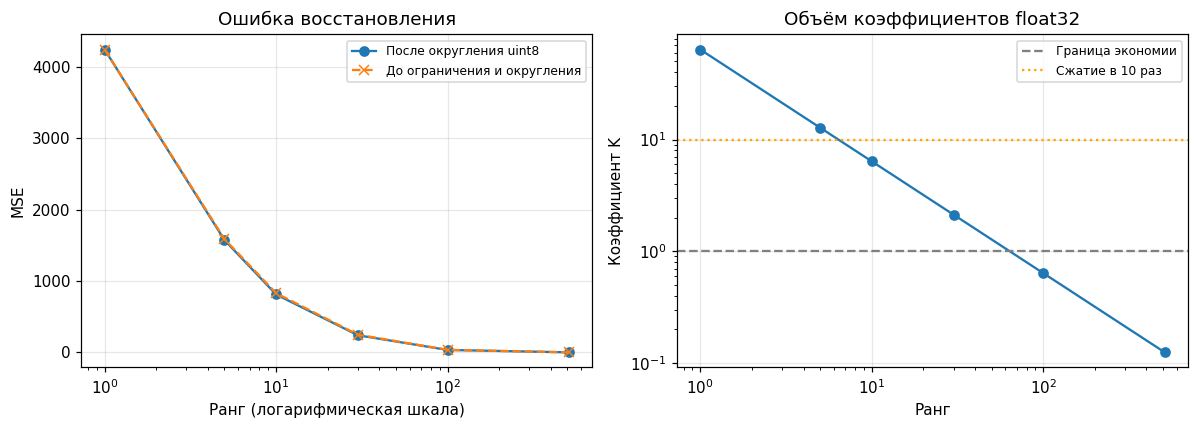

In [4]:
rows = []
for r, approx, ratio, mse in zip(list_of_ranks, approximations, compression_ratios, mse_display):
    payload = {}
    for channel, (U, s, Vt) in enumerate(decompositions):
        payload[f'U{channel}'] = U[:, :r].astype(np.float32)
        payload[f's{channel}'] = s[:r].astype(np.float32)
        payload[f'Vt{channel}'] = Vt[:r, :].astype(np.float32)
    assert sum(a.nbytes for a in payload.values()) == factor_bytes(r)
    npz_path = result_dir / f'factors_rank_{r}.npz'
    png_path = result_dir / f'image_rank_{r}.png'
    np.savez(npz_path, **payload)
    Image.fromarray(approx).save(png_path)
    psnr = float('inf') if mse == 0 else 10 * np.log10(255 ** 2 / mse)
    rows.append([r, factor_bytes(r), ratio, npz_path.stat().st_size,
                 png_path.stat().st_size, mse, psnr])

print(f'{"r":>4} {"Факторы, Б":>12} {"K":>8} {"NPZ, Б":>12} {"PNG, Б":>12} {"MSE uint8":>12} {"PSNR, дБ":>10}')
for r, size, ratio, npz_size, png_size, mse, psnr in rows:
    print(f'{r:4d} {size:12d} {ratio:8.3f} {npz_size:12d} {png_size:12d} {mse:12.4f} {psnr:10.2f}')
rank_10x = int(h * w // (10 * float_bytes * (h + w + 1)))
print(f'Наибольший ранг для сжатия хотя бы в 10 раз: {rank_10x}')
print(f'K(6) = {raw_bytes / factor_bytes(6):.3f}; K(7) = {raw_bytes / factor_bytes(7):.3f}')
print(f'Сжатие относительно RGB есть при целых рангах 1…{int((raw_bytes - 1) // factor_bytes(1))}.')

# Проверяем восстановление из настоящего сохранённого представления float32.
with np.load(result_dir / 'factors_rank_30.npz', allow_pickle=False) as saved:
    restored32 = np.stack([(saved[f'U{j}'] * saved[f's{j}']) @ saved[f'Vt{j}']
                           for j in range(c)], axis=-1)
assert np.allclose(restored32, raw_approximations[3], atol=0.01, rtol=0)
print('NPZ float32 прочитан и восстановлен; максимальное отклонение от float64:',
      f'{np.max(np.abs(restored32 - raw_approximations[3])):.6f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list_of_ranks, mse_display, 'o-', label='После округления uint8')
axes[0].plot(list_of_ranks, mse_raw, 'x--', label='До ограничения и округления')
axes[0].set(xscale='log', xlabel='Ранг (логарифмическая шкала)', ylabel='MSE', title='Ошибка восстановления')
axes[0].legend(fontsize=8)
axes[1].plot(list_of_ranks, compression_ratios, 'o-')
axes[1].axhline(1, color='gray', linestyle='--', label='Граница экономии')
axes[1].axhline(10, color='orange', linestyle=':', label='Сжатие в 10 раз')
axes[1].set(xscale='log', yscale='log', xlabel='Ранг', ylabel='Коэффициент K', title='Объём коэффициентов float32')
axes[1].legend(fontsize=8)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


**Результат части Г.** Ранги 1, 5, 10 и 30 экономят место относительно массива RGB;
для ранга 30 коэффициент составляет около 2,13. При ранге 100 коэффициенты занимают
1 230 000 байт и уже превышают исходные 786 432 байта. При ранге 512 объём факторов
составляет 6 297 600 байт — примерно в 8,01 раза больше исходного.
Наибольший целый ранг для экономии места — 63. Это предел для данной размерности и `float32`,
а не универсальное свойство SVD. Реальные размеры NPZ и PNG приведены в таблице выше;
коэффициент $K$ в ней всегда рассчитан относительно несжатых пикселей.


### Дополнительный анализ: ошибка на тёмных и светлых участках


Тёмные (Y < 85): пикселей 92,958, MSE = 250.776
Средние (85 ≤ Y < 170): пикселей 88,752, MSE = 249.149
Светлые (Y ≥ 170): пикселей 80,434, MSE = 215.622


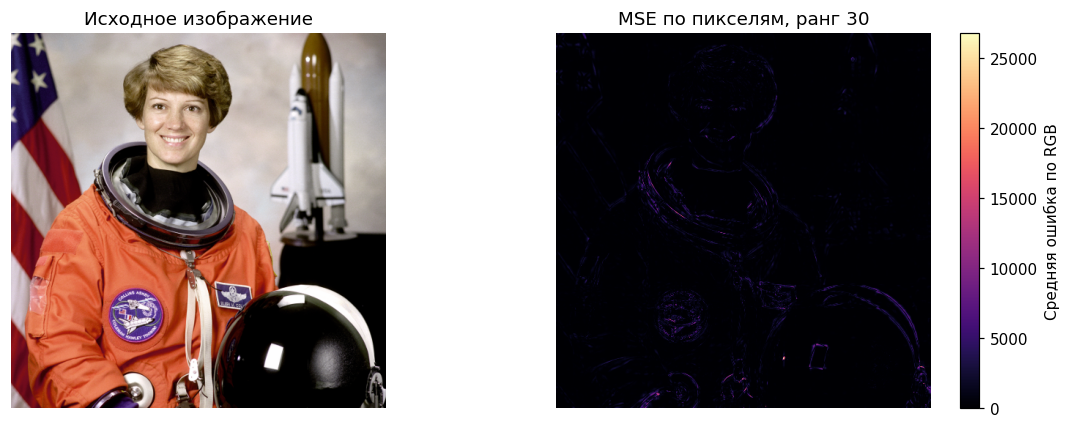

In [5]:
analysis_rank = 30
analysis_image = approximations[list_of_ranks.index(analysis_rank)].astype(np.float64)
luminance = original_float @ np.array([0.299, 0.587, 0.114])
pixel_mse = np.mean((original_float - analysis_image) ** 2, axis=2)
masks = {'Тёмные (Y < 85)': luminance < 85,
         'Средние (85 ≤ Y < 170)': (luminance >= 85) & (luminance < 170),
         'Светлые (Y ≥ 170)': luminance >= 170}
region_errors = {}
for name, mask in masks.items():
    region_errors[name] = float(pixel_mse[mask].mean())
    print(f'{name}: пикселей {mask.sum():,}, MSE = {region_errors[name]:.3f}')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(original)
axes[0].set_title('Исходное изображение')
im = axes[1].imshow(pixel_mse, cmap='magma')
axes[1].set_title('MSE по пикселям, ранг 30')
fig.colorbar(im, ax=axes[1], label='Средняя ошибка по RGB')
for ax in axes:
    ax.axis('off')
fig.tight_layout()
plt.show()


## 3. Ответы на вопросы

**1. При каком ранге визуальное качество перестаёт отличаться от оригинала?**  
Для выбранного изображения при $r=100$ результат близок к оригиналу на уменьшенном общем графике,
но при увеличении различия остаются. Поэтому среди проверенных рангов гарантированное отсутствие
различий можно утверждать для $r=512$: проверено точное равенство округлённых пикселей.
Визуальный порог субъективен и зависит от масштаба просмотра и содержания изображения;
малую MSE нельзя автоматически считать доказательством визуальной неразличимости.

**2. Для какого ранга достигается сжатие в 10 раз?**  
Для этой картинки $K(r)=63{,}93756/r$. Ровно $K=10$ соответствовало бы нецелому
$rpprox6{,}394$. Наибольший допустимый целый ранг для сжатия **не менее чем в 10 раз** — 6:
$K(6)pprox10{,}656$, а $K(7)pprox9{,}134$.
Из обязательного набора подходят ранги 1 и 5; ранг 5 сохраняет больше деталей и даёт $Kpprox12{,}788$.
Ответ относится к факторам `float32` относительно несжатого RGB, а не относительно исходного PNG.

**3. Почему для тёмных/светлых участков ошибка разная?**  
SVD минимизирует общую квадратичную ошибку, а не выравнивает её по областям яркости.
Локальная ошибка зависит от границ, текстур и того, насколько хорошо они описаны сохранёнными компонентами.
Крупные плавные области передаются легче, мелкие контрастные детали — сложнее.
Более высокая яркость сама по себе не означает большую ошибку: при добавлении константы ко всему
изображению структура и спектр могут меняться иначе, чем при изменении текстуры.
Обрезка значений около 0 и 255 также изменяет распределение ошибок.
Для одинаковой абсолютной погрешности относительная ошибка на тёмном участке выше,
но это не то же самое, что абсолютная MSE. Выше приведены измерения по трём маскам яркости
при ранге 30; универсального правила «тёмные всегда хуже» или «светлые всегда хуже» нет.


## 4. Выводы
Цель достигнута: реализовано сжатие цветного изображения отдельным SVD для RGB,
построены все шесть обязательных восстановлений и проверена зависимость ошибки от ранга.
Чем больше ранг, тем точнее восстановление, но тем больше памяти нужно для коэффициентов.
У ранга 30 есть экономия примерно в 2,13 раза ценой потери деталей;
ранг 100 даёт более высокое качество, но уже не экономит память при хранении `float32`.
Десятикратное сжатие возможно при ранге не выше 6 и сопровождается заметной потерей качества.

Полный ранг после округления точно восстанавливает исходные пиксели, однако делает представление
примерно в восемь раз больше несжатого массива. Следовательно, SVD полезно как модель приближения
малого ранга, но увеличение ранга не всегда даёт практическое сжатие.
Размер закодированного PNG и размер SVD-факторов — разные величины; их нельзя подменять друг другом.
Уменьшение ошибки до ограничения и округления подтверждено теоретической формулой,
а для итоговых `uint8`-изображений — обязательной автопроверкой ниже.

### Кратко для защиты
`U` и `Vt` задают пространственные компоненты, `s` — их веса.
Мы оставляем самые большие веса, перемножаем усечённые факторы и собираем три канала.
`full_matrices=False` возвращает экономные размеры (для квадратного изображения размеры совпадают
с полным вариантом). Broadcasting заменяет умножение на диагональную матрицу.
Перед MSE исходные пиксели переводятся в `float64`, чтобы избежать переполнения `uint8`.
В знаменателе коэффициента сжатия обязательно учитываются три канала и четыре байта на `float32`.


## 5. Автоматическая проверка
Следующий блок перенесён из задания без изменений. Переменные `original_shape`,
`original_flat`, `list_of_ranks` и `approximations` подготовлены выше.
Теоретическая монотонность гарантирована для вещественных SVD-приближений;
для округлённых изображений её дополнительно проверяем на выбранных рангах.


In [6]:
# ---------- БЛОК АВТОПРОВЕРКИ (НЕ РЕДАКТИРОВАТЬ) ----------
# Предполагается, что у вас есть переменные:
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")


✅ Все автоматические проверки пройдены. Задание выполнено корректно!
